Files already downloaded and verified
Files already downloaded and verified
Successfully created datasets with the following transforms:
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


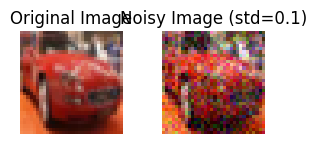

In [8]:
import torch
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the custom transform class for adding noise
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.1):
        self.std = std
        self.mean = mean
        
    def __call__(self, tensor):
        noise = torch.randn(tensor.size()) * self.std + self.mean
        noisy_tensor = tensor + noise
        return torch.clamp(noisy_tensor, 0., 1.)

# --- User's code modified to include the noise transform ---

# Parameters (you can set these)
transfer_learning = True
dataset_name = 'cifar10'
add_noise = True  # Set to True to add noise
noise_std = 0.1   # Control the amount of noise

# Define the transforms
if transfer_learning:
    transform_list = [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ]
    if add_noise:
        # Add noise after converting to tensor
        transform_list.append(AddGaussianNoise(mean=0., std=noise_std))
    
    # Normalization should be the last step
    transform_list.append(
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    )
    transform = transforms.Compose(transform_list)
else:
    transform_list = []
    if dataset_name == 'mnist':
        transform_list.append(transforms.Grayscale(num_output_channels=3))
        
    transform_list.append(transforms.ToTensor())
    
    if add_noise:
        # Add noise after converting to tensor
        transform_list.append(AddGaussianNoise(mean=0., std=noise_std))
        
    transform = transforms.Compose(transform_list)

# Load the datasets with the new transform
if dataset_name == 'mnist':
    train_dset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    test_dset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
    num_classes = 10
elif dataset_name == 'cifar10':
    train_dset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
    test_dset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
    num_classes = 10
else: 
    raise ValueError(f"Unknown image dataset: {dataset_name}")

print("Successfully created datasets with the following transforms:")
print(train_dset.transform)

# --- Visualization to show the effect ---

# Get a sample image from the dataset
# Note: For visualization, we use a simpler transform without normalization
# to see the direct effect of noise on a [0, 1] scale image.
transform_original = transforms.Compose([transforms.ToTensor()])
transform_noisy = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=0., std=noise_std)
])

cifar_for_viz = datasets.CIFAR10(root='./data', train=True, transform=transform_original, download=False)
cifar_for_viz_noisy = datasets.CIFAR10(root='./data', train=True, transform=transform_noisy, download=False)

# Get the same image with and without noise
img_original, _ = cifar_for_viz[5]  # The 6th image
img_noisy, _ = cifar_for_viz_noisy[5]

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(3, 1.5))
axs[0].imshow(img_original.permute(1, 2, 0))
axs[0].set_title('Original Image')
axs[0].axis('off')

axs[1].imshow(img_noisy.permute(1, 2, 0))
axs[1].set_title(f'Noisy Image (std={noise_std})')
axs[1].axis('off')

plt.tight_layout()
plt.show()
